_This Notebook standardizes the habitat data. It also explains the reasoning behind the adoptation of the Gelderland dataset as ground truth._

## Importing Functions

In [1]:
from functions.gpkg_funcs import (
    import_gpkg_func,
)

from functions.custom_common_nb_funcs import (
    check_processing,
)

## Setting directory

In [2]:
from paths.OG_paths import (
    #######################################
    #     HABITAT / VEGETATION DATA       #
    #######################################
    # |   T0 Habitatkart Veluwe [RAW]     |
    # +===================================+ 
    habitat_kart__raw__gelderland__RD__gpkg_path,
    habitat_kart__raw__website__RD__gpkg_path,


    #######################################
    #     01_pre_processing_hab_kart      #
    #######################################
    # |  n01_T0_habitat_gpkg_processing   |
    # +===================================+ 
    # --- Habitat kart Indexed GPKGs (saved as xlsx) --- #
    habitat_kart__indexed__gelderland__RD__xlsx_path,
    habitat_kart__indexed__gelderland_minHR__RD__xlsx_path,
    habitat_kart__indexed__website__RD__xlsx_path,
    habitat_kart__indexed__website_plusHR__RD__xlsx_path,

    # --- Habitat kart Processed GPKGs --- #
    # RD
    habitat_kart__processed__gelderland__RD__gpkg_path,
    habitat_kart__processed__gelderland_minHR__RD__gpkg_path,
    habitat_kart__processed__website__RD__gpkg_path,
    habitat_kart__processed__website_plusHR__RD__gpkg_path,
    # WGS84
    habitat_kart__processed__gelderland__WGS84__gpkg_path,
    habitat_kart__processed__gelderland_minHR__WGS84__gpkg_path,
    habitat_kart__processed__website__WGS84__gpkg_path,
    habitat_kart__processed__website_plusHR__WGS84__gpkg_path,
    # UTM32631
    habitat_kart__processed__gelderland__UTM32631__gpkg_path,
    habitat_kart__processed__gelderland_minHR__UTM32631__gpkg_path,
    habitat_kart__processed__website__UTM32631__gpkg_path,
    habitat_kart__processed__website_plusHR__UTM32631__gpkg_path,


    #######################################
    #            00_common_dfs            #
    #######################################
    # |    n01_habitat_reference_dfs      |
    # +===================================+ 
    habitat_reference__WD__df_path,
)

## Importing packages

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)

In [4]:
# REPORT PLOTTING

FONT_FAMILY   = "Arial"         
TITLE_SIZE    = 11
LABEL_SIZE    = 10
TICK_SIZE     = 9
DPI           = 300              
CB_COLORS = ["#999999","#0072B2", "#E69F00", "#009E73", "#CC79A7",
             "#56B4E9", "#D55E00", "#F0E442"]

plt.rcParams.update({
    "font.family":       FONT_FAMILY,
    "font.size":         LABEL_SIZE,
    "axes.titlesize":    TITLE_SIZE,
    "axes.labelsize":    LABEL_SIZE,
    "xtick.labelsize":   TICK_SIZE,
    "ytick.labelsize":   TICK_SIZE,
    "axes.spines.top":   False,    
    "axes.spines.right": False,
    "axes.grid":         True,
    "axes.grid.axis":    "y", 
    "grid.linewidth":    0.5,
    "grid.alpha":        0.5,
})

## Importing Files

In [5]:
# --- Gelderland raw data ---
habitat_kart__raw__gelderland__RD__gdf = import_gpkg_func(
    gdf_path=habitat_kart__raw__gelderland__RD__gpkg_path, 
    layer='habitat',
    reindex="fid"
)

# --- Website raw data ---
habitat_kart__raw__website__RD__gdf = import_gpkg_func(
    gdf_path=habitat_kart__raw__website__RD__gpkg_path,
    layer='Na_Na_Habitattyp_Actueel',
    reindex="fid"
)

# --- Robust Names df ---
habitat_reference__WD__df = pd.read_pickle(habitat_reference__WD__df_path)

c:\Users\NL1G3K\Desktop\Vegetation_quality_monitoring\.pixi\envs\default\Lib\site-packages\pyogrio\geopandas.py:49: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  res = pd.to_datetime(ser, **datetime_kwargs)
c:\Users\NL1G3K\Desktop\Vegetation_quality_monitoring\.pixi\envs\default\Lib\site-packages\pyogrio\geopandas.py:49: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  res = pd.to_datetime(ser, **datetime_kwargs)
c:\Users\NL1G3K\Desktop\Vegetation_quality_monitoring\.pixi\envs\default\Lib\site-packages\pyogrio\geopandas.py:49: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  res = pd.to_datetime(ser, **datetime_kwargs)
c:\Users\NL1G3K\Desktop\V

## Quick input plot

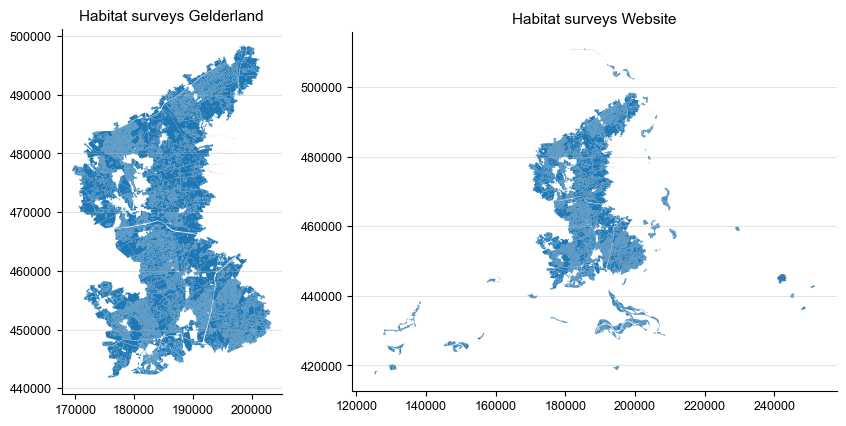

In [6]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(10, 8),
    gridspec_kw={"width_ratios": [1, 2.2]}
)

habitat_kart__raw__gelderland__RD__gdf.plot(ax=ax1)
ax1.set_title("Habitat surveys Gelderland")

habitat_kart__raw__website__RD__gdf.plot(ax=ax2)
ax2.set_title("Habitat surveys Website");

## Selecting col's from Gelderland GDF

In [7]:
# habitat_kart__raw__gelderland__RD__gdf.columns

In [8]:
selected_cols_to_keep = ['OBJECTID', 'bron', 'veldSituatieDatum', 'habitatType1', 'Habitatnaam_1', 
                         'bedekkingsOppervlakte1', 'bedekkingsPercentage1', 'habitatType2', 
                         'Habitatnaam_2', 'bedekkingsOppervlakte2', 'bedekkingsPercentage2', 
                         'Shape_Area', 'geometry']

habitat_kart__raw__gelderland__RD__gdf = habitat_kart__raw__gelderland__RD__gdf[selected_cols_to_keep]

In [9]:
habitat_kart__raw__gelderland__RD__gdf.columns

Index(['OBJECTID', 'bron', 'veldSituatieDatum', 'habitatType1',
       'Habitatnaam_1', 'bedekkingsOppervlakte1', 'bedekkingsPercentage1',
       'habitatType2', 'Habitatnaam_2', 'bedekkingsOppervlakte2',
       'bedekkingsPercentage2', 'Shape_Area', 'geometry'],
      dtype='object')

## Making the website GDF uniform to that

In [10]:
# habitat_kart__raw__website__RD__gdf.columns

In [11]:
rename_dict = {
    'objectid': 'OBJECTID',
    'bron': 'bron',
    'veldsituatiedatum': 'veldSituatieDatum',
    'habitattype1': 'habitatType1',
    'habitatnaam_1': 'Habitatnaam_1',
    'bedekkingsoppervlakte1': 'bedekkingsOppervlakte1',
    'bedekkingspercentage1': 'bedekkingsPercentage1',
    'habitattype2': 'habitatType2',
    'habitatnaam_2': 'Habitatnaam_2',
    'bedekkingsoppervlakte2': 'bedekkingsOppervlakte2',
    'bedekkingspercentage2': 'bedekkingsPercentage2',
    'st_area_shape_': 'Shape_Area',
    'geometry': 'geometry'
}

habitat_kart__raw__website__RD__gdf = habitat_kart__raw__website__RD__gdf[list(rename_dict.keys())].rename(columns=rename_dict)

In [12]:
habitat_kart__raw__website__RD__gdf.columns

Index(['OBJECTID', 'bron', 'veldSituatieDatum', 'habitatType1',
       'Habitatnaam_1', 'bedekkingsOppervlakte1', 'bedekkingsPercentage1',
       'habitatType2', 'Habitatnaam_2', 'bedekkingsOppervlakte2',
       'bedekkingsPercentage2', 'Shape_Area', 'geometry'],
      dtype='object')

## Adding an unique index

In [13]:
# --- Gelderland ---
habitat_kart__indexed__gelderland__RD__gdf = habitat_kart__raw__gelderland__RD__gdf.reset_index(drop=True)
habitat_kart__indexed__gelderland__RD__gdf.index = [f"GI_{i}" for i in range(1, len(habitat_kart__indexed__gelderland__RD__gdf) + 1)]
habitat_kart__indexed__gelderland__RD__gdf.index.name = 'index'

In [14]:
# --- Website ---
habitat_kart__indexed__website__RD__gdf = habitat_kart__raw__website__RD__gdf.reset_index(drop=True)
habitat_kart__indexed__website__RD__gdf.index = [f"WI_{i}" for i in range(1, len(habitat_kart__indexed__website__RD__gdf) + 1)]
habitat_kart__indexed__website__RD__gdf.index.name = 'index'

In [15]:
habitat_kart__indexed__website__RD__gdf.iloc[0:1]

,OBJECTID,bron,veldSituatieDatum,habitatType1,Habitatnaam_1,bedekkingsOppervlakte1,bedekkingsPercentage1,habitatType2,Habitatnaam_2,bedekkingsOppervlakte2,bedekkingsPercentage2,Shape_Area,geometry
index,,,,,,,,,,,,,
WI_1,69,Veldbezoek 2009,2009-12-30 23:00:00+00:00,H0000,Geen habitattype (met zekerheid),4811.641622,100,None,None,0.0,0.0,4811.675836,"POLYGON ((229073.163 459210.472, 229066.156 459203.188, 229004.151 459138.741, 228961.87 459165.65, 228960.228 459166.695, 228965.337 459171.043, 228965.986 459170.729, 228970.142 459174.261, 228979.717 459183.29, 229017.641 459219.98, 229036.467 459237.307, 229039.466 459235.114, 229073.163 459210.472))"


In [16]:
habitat_kart__indexed__gelderland__RD__gdf['habitatType1'].unique()

array(['H4030', 'H0000', 'H2330', 'H9120', 'ZGH3130', 'H91E0C', 'H2310',
       'H3260A', 'ZGH6230', 'ZGH2330', 'ZGH4030', 'ZGH9190', 'H9190',
       'H6230', 'H4010A', 'H3130', 'H3160', 'H7110B', 'H7150', 'ZGH9120',
       'ZGH7110B', 'ZGH2310', 'H91F0', 'H91D0', 'H2320', 'H5130', 'H6410',
       'ZGH2320', 'ZGH91E0C', 'ZGH91E0B', 'ZGH3160', 'ZGH5130', 'H91E0B',
       'H7140A', 'H7230', 'ZGH3260A', 'H91E0A'], dtype=object)

In [17]:
habitat_kart__indexed__website__RD__gdf['habitatType1'].unique()

array(['H0000', 'H3130', 'H4010A', 'H4030', 'H7230', 'H91E0C', 'H6410',
       'H9120', 'H6230', 'H7150', 'H9190', 'H91E0A', 'H91E0B', 'H91F0',
       'H6510A', 'H3150', 'H6120', 'ZGH6510A', 'H6430A', 'H7140A',
       'ZGH3150', 'H3260A', 'H9160A', 'H5130', 'H2310', 'H7120',
       'ZGH91E0A', 'ZGH91F0', 'ZGH6430A', 'H9999', 'ZGH3270', 'H7210',
       'H3270', 'H6430C', 'H2330', 'ZGH6510B', 'H6510B', 'ZGH4030',
       'ZGH91E0C', 'H3260B', 'H6430B', 'H7110A', 'H91D0', 'H3160',
       'ZGH91E0B', 'ZGH2330', 'ZGH6230', 'ZGH9120', 'ZGH5130', 'H2320',
       'ZGH2310', 'ZGH3130', 'ZGH9190', 'ZGH3260A', 'H7110B', 'ZGH3160',
       'ZGH2320', 'ZGH7110B'], dtype=object)

## Checking the survey source timestamps

In [18]:
# setting the date col to datetime
habitat_kart__indexed__gelderland__RD__gdf["veldSituatieDatum"] = pd.to_datetime(habitat_kart__indexed__gelderland__RD__gdf["veldSituatieDatum"])
habitat_kart__indexed__website__RD__gdf["veldSituatieDatum"] = pd.to_datetime(habitat_kart__indexed__website__RD__gdf["veldSituatieDatum"])

In [19]:
# counting the no. of surveys per date
habitat_kart__indexed__gelderland__RD__counts = (habitat_kart__indexed__gelderland__RD__gdf
          .assign(day=habitat_kart__indexed__gelderland__RD__gdf["veldSituatieDatum"].dt.date)
          .groupby("day")
          .size()
          .sort_index())

habitat_kart__indexed__website__RD__counts = (habitat_kart__indexed__website__RD__gdf
          .assign(day=habitat_kart__indexed__website__RD__gdf["veldSituatieDatum"].dt.date)
          .groupby("day")
          .size()
          .sort_index())

In [20]:
# setting a minimum of 30 surveys to aid readability
min_count_30 = 50

habitat_kart__indexed__gelderland__RD__counts_filt = habitat_kart__indexed__gelderland__RD__counts[habitat_kart__indexed__gelderland__RD__counts >= min_count_30]
habitat_kart__indexed__website__RD__counts_filt = habitat_kart__indexed__website__RD__counts[habitat_kart__indexed__website__RD__counts >= min_count_30]

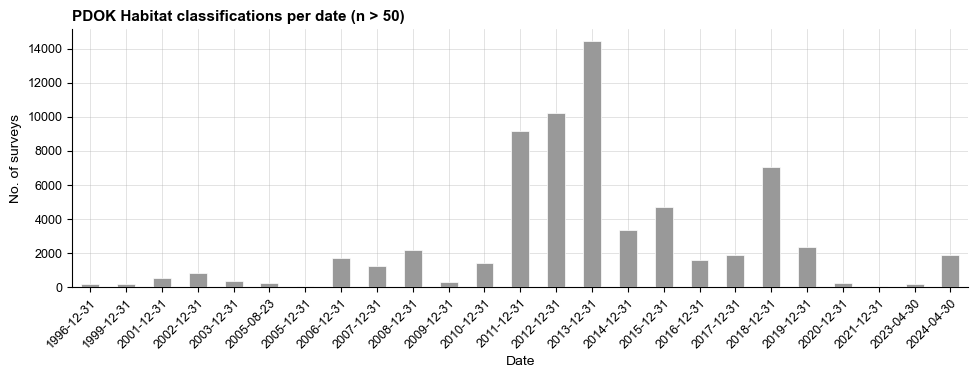

In [21]:
# --- Plot ---
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4), sharex=False)

habitat_kart__indexed__website__RD__counts_filt.plot(
    kind="bar", ax=ax1, color=CB_COLORS[0],
    edgecolor="white", linewidth=0.5, zorder=3
)

title = f"PDOK Habitat classifications per date (n > {min_count_30})"


ax1.set_title(title, loc="left", fontweight="bold")  # Left-aligned: Springer convention
ax1.set_ylabel("No. of surveys")
ax1.set_xlabel("Date")
ax1.set_xticks(range(len(ax1.get_xticklabels())))
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax1.yaxis.set_major_locator(plt.MaxNLocator(integer=True))  # Integer y-ticks only

plt.tight_layout(pad=1.5)
plt.show()

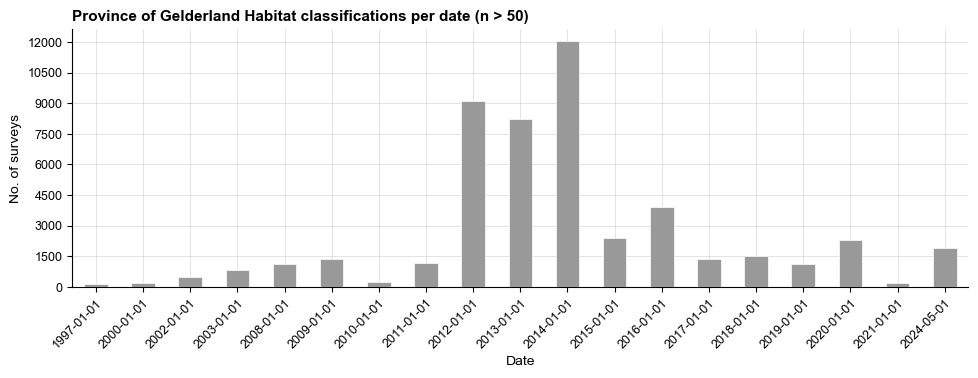

In [22]:
# --- Plot ---
fig, ax2 = plt.subplots(1, 1, figsize=(10, 4), sharex=False)

habitat_kart__indexed__gelderland__RD__counts_filt.plot(
    kind="bar", ax=ax2, color=CB_COLORS[0],
    edgecolor="white", linewidth=0.5, zorder=3
)

title = f"Province of Gelderland Habitat classifications per date (n > {min_count_30})"


ax2.set_title(title, loc="left", fontweight="bold")  # Left-aligned: Springer convention
ax2.set_ylabel("No. of surveys")
ax2.set_xlabel("Date")
ax2.set_xticks(range(len(ax2.get_xticklabels())))
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))  # Integer y-ticks only

plt.tight_layout(pad=1.5)
plt.show()

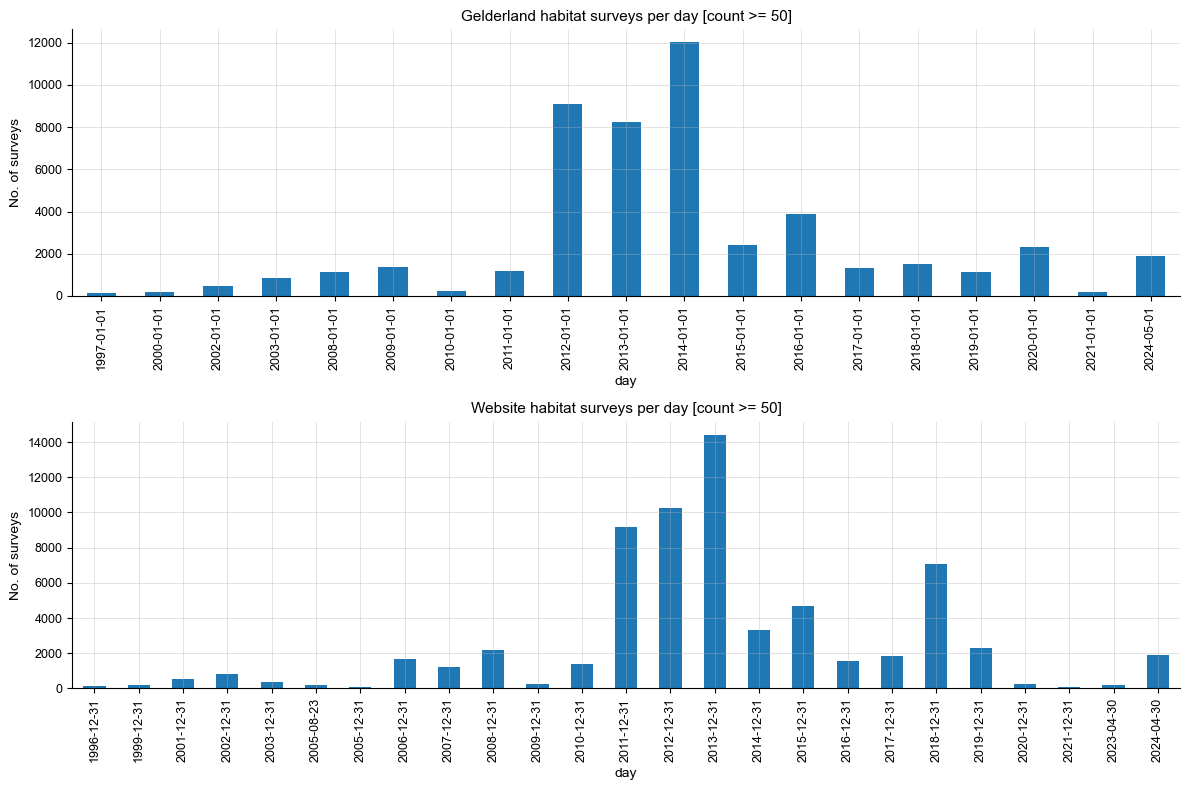

In [23]:
# plotting the surveys per day
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

habitat_kart__indexed__gelderland__RD__counts_filt.plot(kind="bar", ax=ax1)
ax1.set_ylabel("No. of surveys")
ax1.set_title(f"Gelderland habitat surveys per day [count >= {min_count_30}]")

habitat_kart__indexed__website__RD__counts_filt.plot(kind="bar", ax=ax2)
ax2.set_ylabel("No. of surveys")
ax2.set_title(f"Website habitat surveys per day [count >= {min_count_30}]")

plt.tight_layout()
plt.show()

_One might notice the fact that for the website (almost) all data set on the 31st of December, where the Gelderland dataset has all data on the first of Jan. Below it is shown that a UTC timezone is passed to the DF which is t-1 [hr] from our timezone._

In [24]:
# --- Gelderland
print("dtype:", habitat_kart__indexed__gelderland__RD__gdf["veldSituatieDatum"].dtype)
print("tz:", getattr(habitat_kart__indexed__gelderland__RD__gdf["veldSituatieDatum"].dt, "tz", None)) 

dtype: datetime64[ms, UTC]
tz: UTC


In [25]:
# --- Website ---
print("dtype:", habitat_kart__indexed__website__RD__gdf["veldSituatieDatum"].dtype)
print("tz:", getattr(habitat_kart__indexed__website__RD__gdf["veldSituatieDatum"].dt, "tz", None)) 

dtype: datetime64[ms, UTC]
tz: UTC


_Now note the fact that for the surveys in the Website df all are set to 23hrs on the 31st of December_

In [26]:
habitat_kart__indexed__website__RD__dec31_df = (
    habitat_kart__indexed__website__RD__gdf.loc[(habitat_kart__indexed__website__RD__gdf["veldSituatieDatum"].dt.month == 12) & 
                                        (habitat_kart__indexed__website__RD__gdf["veldSituatieDatum"].dt.day == 31), "veldSituatieDatum"]
      .dropna()
      .unique()
      .tolist()
)

In [27]:
habitat_kart__indexed__website__RD__dec31_df[0:5]

[Timestamp('2012-12-31 23:00:00+0000', tz='UTC'),
 Timestamp('2008-12-31 23:00:00+0000', tz='UTC'),
 Timestamp('2014-12-31 23:00:00+0000', tz='UTC'),
 Timestamp('2013-12-31 23:00:00+0000', tz='UTC'),
 Timestamp('2019-12-31 23:00:00+0000', tz='UTC')]

_The following plot shows what happens when one of the DF's is moved by just one hour:_ <br>
--> Gelderland is moved one hour back in time <br>
--> Website is moved one hour later in time 

In [28]:
# Building a Gelderland - hr df
habitat_kart__indexed__gelderland_minHR__RD__gdf = habitat_kart__indexed__gelderland__RD__gdf.copy()
habitat_kart__indexed__gelderland_minHR__RD__gdf['veldSituatieDatum'] = (
    habitat_kart__indexed__gelderland_minHR__RD__gdf['veldSituatieDatum'] - pd.Timedelta(hours=1)
)
habitat_kart__indexed__gelderland_minHR__RD__gdf.index = habitat_kart__indexed__gelderland_minHR__RD__gdf.index.to_series().str.replace(r"^GI_", "GI_hr_", regex=True)

# Building a Website + hr df
habitat_kart__indexed__website_plusHR__RD__gdf = habitat_kart__indexed__website__RD__gdf.copy()
habitat_kart__indexed__website_plusHR__RD__gdf['veldSituatieDatum'] = (
    habitat_kart__indexed__website_plusHR__RD__gdf['veldSituatieDatum'] + pd.Timedelta(hours=1)
)
habitat_kart__indexed__website_plusHR__RD__gdf.index = habitat_kart__indexed__website_plusHR__RD__gdf.index.to_series().str.replace(r"^WI_", "WI_hr_", regex=True)

In [29]:
# counting the no. of surveys per date of new dfs
habitat_kart__indexed__gelderland_minHR__RD__counts = (habitat_kart__indexed__gelderland_minHR__RD__gdf
          .assign(day=habitat_kart__indexed__gelderland_minHR__RD__gdf["veldSituatieDatum"].dt.date)
          .groupby("day")
          .size()
          .sort_index())

habitat_kart__indexed__website_plusHR__RD__counts = (habitat_kart__indexed__website_plusHR__RD__gdf
          .assign(day=habitat_kart__indexed__website_plusHR__RD__gdf["veldSituatieDatum"].dt.date)
          .groupby("day")
          .size()
          .sort_index())

In [30]:
# Again filter for +30 surveys
habitat_kart__indexed__gelderland_minHR__RD__counts_filt = habitat_kart__indexed__gelderland_minHR__RD__counts[habitat_kart__indexed__gelderland_minHR__RD__counts >= min_count_30]
habitat_kart__indexed__website_plusHR__RD__counts_filt = habitat_kart__indexed__website_plusHR__RD__counts[habitat_kart__indexed__website_plusHR__RD__counts >= min_count_30]

In [31]:
# New temp dfs for plotting
# --- Original timestamps ---
df_top = pd.concat(
    [habitat_kart__indexed__gelderland__RD__counts_filt.rename("Gelderland"),
     habitat_kart__indexed__website__RD__counts_filt.rename("PDOK")],
    axis=1
).fillna(0)
df_top = df_top.sort_index()

# --- Website +1 hr ---
df_middle = pd.concat(
    [habitat_kart__indexed__gelderland__RD__counts_filt.rename("Gelderland"),
     habitat_kart__indexed__website_plusHR__RD__counts_filt.rename("PDOK (+1hr)")],
    axis=1
).fillna(0)
df_middle = df_middle.sort_index()

# --- Gelderland -1 hr ---
df_bottom = pd.concat(
    [habitat_kart__indexed__gelderland_minHR__RD__counts_filt.rename("Gelderland (-1hr)"),
     habitat_kart__indexed__website__RD__counts_filt.rename("PDOK")],
    axis=1
).fillna(0)
df_bottom = df_bottom.sort_index()

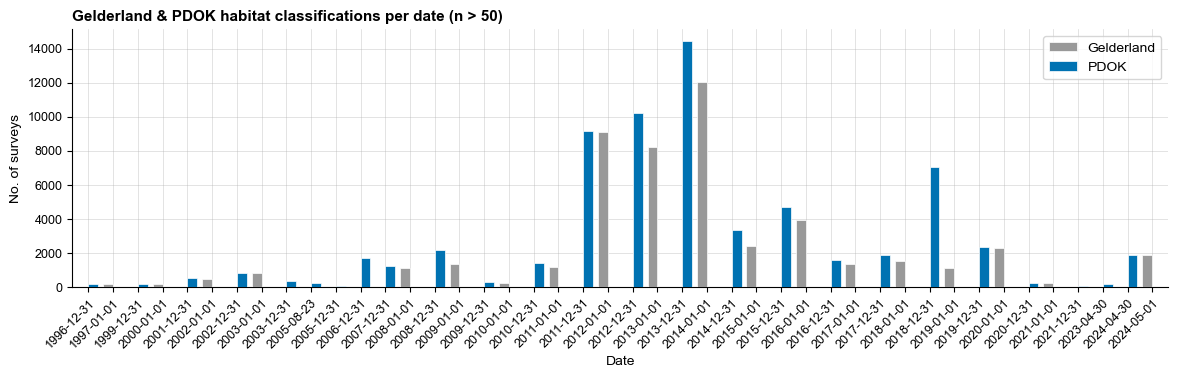

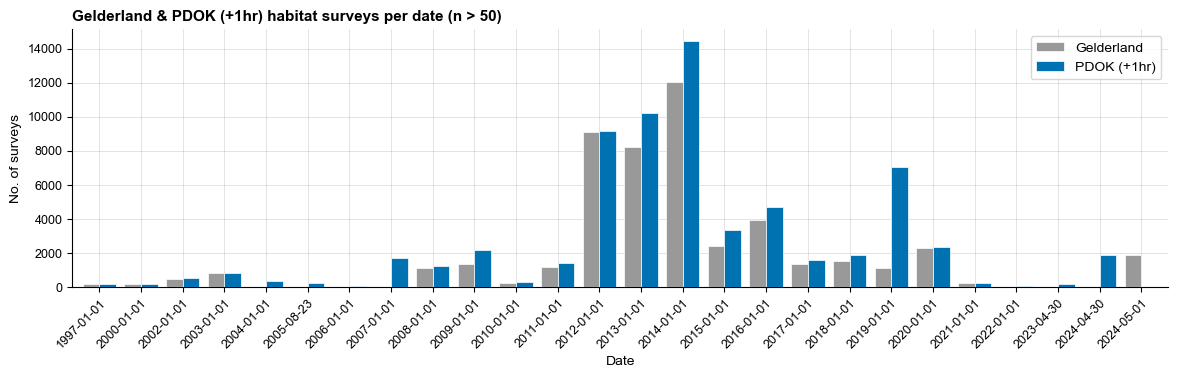

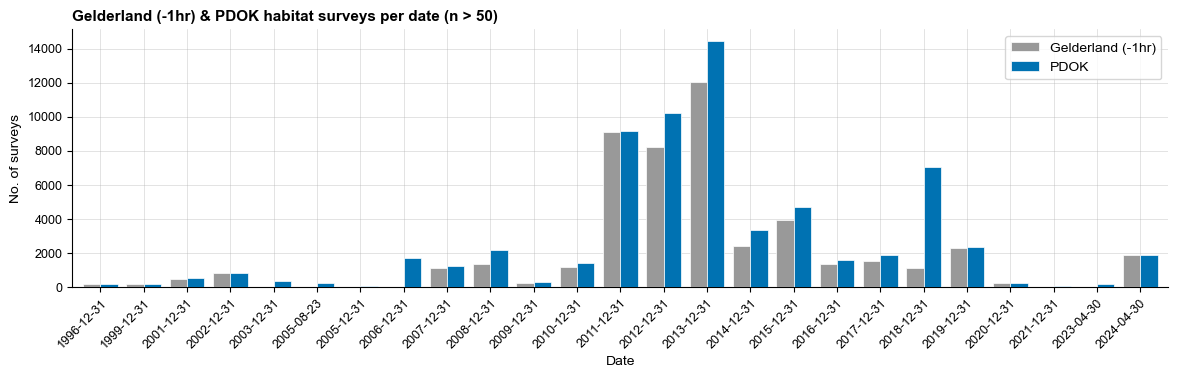

In [32]:
def plot_surveys(df, title, colors=None):
    if colors is None:
        colors = [CB_COLORS[0], CB_COLORS[1]]
    
    fig, ax = plt.subplots(figsize=(12, 4))
    df.plot(kind="bar", ax=ax, color=colors, width=0.8, edgecolor="white", linewidth=0.5, zorder=3)
    ax.set_ylabel("No. of surveys")
    ax.set_xlabel("Date")
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xticks(range(len(ax.get_xticklabels())))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend()
    plt.tight_layout(pad=1.5)
    plt.show()

plot_surveys(df_top,    f"Gelderland & PDOK habitat classifications per date (n > {min_count_30})")
plot_surveys(df_middle, f"Gelderland & PDOK (+1hr) habitat surveys per date (n > {min_count_30})")
plot_surveys(df_bottom, f"Gelderland (-1hr) & PDOK habitat surveys per date (n > {min_count_30})")

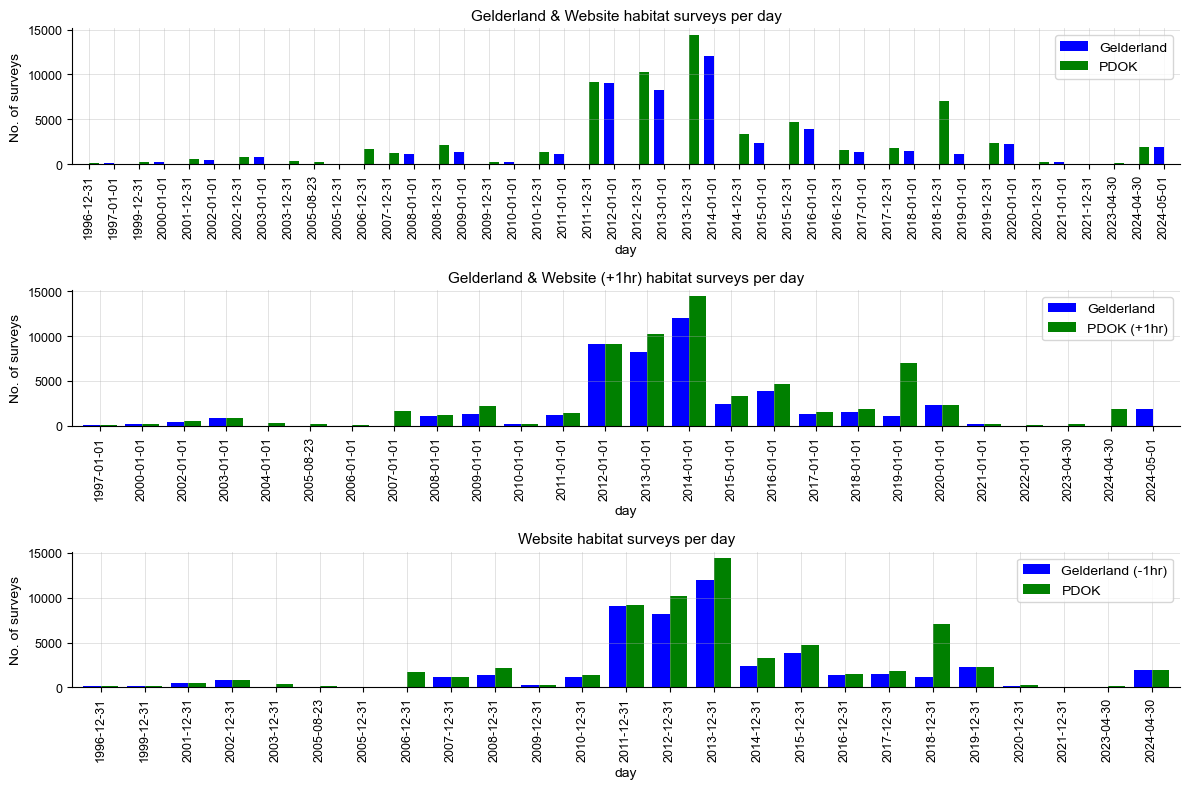

In [33]:
# Plotting
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

df_top.plot(kind="bar", ax=ax1, color=["Blue", "Green"], width=0.8)
ax1.set_ylabel("No. of surveys")
ax1.set_title(f"Gelderland & Website habitat surveys per day")
ax1.legend()

df_middle.plot(kind="bar", ax=ax2, color=["Blue", "Green"], width=0.8)
ax2.set_ylabel("No. of surveys")
ax2.set_title(f"Gelderland & Website (+1hr) habitat surveys per day")
ax2.legend()

df_bottom.plot(kind="bar", ax=ax3, color=["Blue", "Green"], width=0.8)
ax3.set_ylabel("No. of surveys")
ax3.set_title(f"Website habitat surveys per day")
ax3.legend()

plt.tight_layout()
plt.show()

_In the above plot is becomes clear that one of the gpkg's contains (one hour) shifted surveys. But both shifts are theoretically possible (see explanation below). To figure out which should be True, the "veldSituatieDatum" column is checked against the source._

_Explanation_
_Note the fact that both datasets are in UTC. This is -1 hour compared to the Netherlands. Given the fact that the current data is in UTC these are the two possible things that happened:_

1. _TRUE = 1 Jan 00:00hrs [local time]_ <br>
_--> The Website database is correct, but very misleading with the 31 Dec 23:00hrs timestamp (in the previous year)._  <br>
_--> The Gelderland database was saved incorrectly, as the 00:00hrs local time was saved as 00:00hrs UTC_ <br>

2. _TRUE = 31 Dec 23:00hrs [local time]_ <br>
_--> The Website database was saved incorrectly, as the 23:00hrs local time was saved as 23:00 UTC_ <br>
_--> The Gelderland database was saved incorrectly, as the 23:00hrs local time was saved as 23:00 UTC. Then downloaded and converted to 00:00 local time, but then saved incorrectly again as 00:00hrs UTC_

In [34]:
# --- Gelderland ---
# Filter on 1 jan and keep needed columns
habitat_kart__indexed__gelderland__RD__jan1_df = habitat_kart__indexed__gelderland__RD__gdf.loc[
    (habitat_kart__indexed__gelderland__RD__gdf["veldSituatieDatum"].dt.month == 1)
    & (habitat_kart__indexed__gelderland__RD__gdf["veldSituatieDatum"].dt.day == 1),
    ["veldSituatieDatum", "bron"],
].dropna(subset=["veldSituatieDatum"])

# Create date column (drop time)
habitat_kart__indexed__gelderland__RD__jan1_df["datum"] = habitat_kart__indexed__gelderland__RD__jan1_df["veldSituatieDatum"].dt.floor("D")

# One row per date with list of bron-values
gelderland_bron_per_datum_df = (
    habitat_kart__indexed__gelderland__RD__jan1_df.groupby("datum", as_index=False)
         .agg(
             n_records=("bron", "size"),
             n_bron_unique=("bron", lambda s: s.nunique(dropna=True)),
             bron_list=("bron", lambda s: sorted(s.dropna().unique().tolist())),
         )
         .sort_values("datum")
         .reset_index(drop=True)
)

# --- Website ---
# Filter on 31 Dec and keep needed columns
habitat_kart__indexed__website__RD__dec31_df = habitat_kart__indexed__website__RD__gdf.loc[
    (habitat_kart__indexed__website__RD__gdf["veldSituatieDatum"].dt.month == 12)
    & (habitat_kart__indexed__website__RD__gdf["veldSituatieDatum"].dt.day == 31),
    ["veldSituatieDatum", "bron"],
].dropna(subset=["veldSituatieDatum"])

# Create date column (drop time)
habitat_kart__indexed__website__RD__dec31_df["datum"] = habitat_kart__indexed__website__RD__dec31_df["veldSituatieDatum"].dt.floor("D")

# One row per date with list of bron-values
website_bron_per_datum_df = (
    habitat_kart__indexed__website__RD__dec31_df.groupby("datum", as_index=False)
         .agg(
             n_records=("bron", "size"),
             n_bron_unique=("bron", lambda s: s.nunique(dropna=True)),
             bron_list=("bron", lambda s: sorted(s.dropna().unique().tolist())),
         )
         .sort_values("datum")
         .reset_index(drop=True)
)

In [35]:
gelderland_bron_per_datum_df[17:21]

,datum,n_records,n_bron_unique,bron_list
17,2019-01-01 00:00:00+00:00,1134,11,"[Berglinde-2016, Natuurbalans-2019a, Bosgroepen-2012, Natuurbalans-2019a, Bosgroepen-2019, Courbois-2019, Courbois-2019a, Defensie-2019, Defensie-2019, Natuurbalans-2020, Natuurbalans-2019, Natuurbalans-2019a, Natuurbalans-2019b, Natuurbalans-2020b]"
18,2020-01-01 00:00:00+00:00,2301,14,"[Berglinde-2013c, VdG&G: Bernard Oosterbaan, Berglinde-2018, VdG&G: Tom Damm, Courbois-2019a, Courbois-2020, Courbois-2020, Natuurbalans-2020, LNV-2015, Natuurbalans-2020b, Natuurbalans-2020, Natuurbalans-2020a, Natuurbalans-2020b, Natuurbalans-2020b, Courbois-2019a, Natuurbalans-2020b, Natuurbalans-2021a, Natuurbalans-2020c, prvGld-2020, prvGld-2020, Natuurbalans-2020]"
19,2021-01-01 00:00:00+00:00,207,2,"[Natuurbalans-2021, Natuurbalans-2021a]"
20,2022-01-01 00:00:00+00:00,15,2,"[Natuurbalans-2022, Simons-2022]"


In [36]:
website_bron_per_datum_df[22:26]

,datum,n_records,n_bron_unique,bron_list
22,2019-12-31 00:00:00+00:00,2317,15,"[Berglinde-2013c, VdG&G: Bernard Oosterbaan, Berglinde-2018, VdG&G: Tom Damm, Courbois-2019a, Courbois-2020, Courbois-2020, Natuurbalans-2020, LNV-2015, Natuurbalans-2020b, Natuurbalans-2020, Natuurbalans-2020a, Natuurbalans-2020b, Natuurbalans-2020b, Courbois-2019a, Natuurbalans-2020b, Natuurbalans-2021a, Natuurbalans-2020c, Natuurbalans-2022a, prvGld-2020, prvGld-2020, Natuurbalans-2020]"
23,2020-12-31 00:00:00+00:00,251,7,"[Bargerveen-2021, Berglinde-2014, prvGld-2014, vDelft-2020, NBLD-2020, NBLD-2020, NBLD-2021, NBLD-2021, Natuurbalans-2021, Natuurbalans-2021a]"
24,2021-12-31 00:00:00+00:00,69,6,"[Berglinde-2019, Natuurbalans-2022, WUR-2022, Berglinde-2019, Natuurbalans-2022b, Natuurbalans-2022, Natuurbalans-2022, WUR-2022, Natuurbalans-2022b, Simons-2022]"
25,2022-12-31 00:00:00+00:00,49,4,"[Geldersch Landschap-2023, Natuurbalans-2023, Natuurbalans-2023, prvGld-2023, Natuurbalans-2023a]"


_Taking the following four considerations into account:_ <br>
1. _The survey source seems to better match for the Gelderland & Website +1 hr gdfs_ <br>
2. _In an interview an employee of Gelderland appointed the 1st of Jan as more propable_ <br>
3. _An 00:00 entry seems more logical than a 23hrs entry in such a df_ <br>
4. _If the 31st ends up being True, than it is reasonable to assume that this still holds for 1st of Jan (next year)_ <br>

_It is decided to assume that the "Gelderland" and "Website plus hr" gdfs are True. Nonetheless, all four gdfs will be continued to work with if this assumption is invalidated_

## Removing timezone and timestampe + adding years & month col

In [37]:
# Removing timezone & timestamp from the gdfs
habitat_kart__indexed__gelderland__RD__gdf['veldSituatieDatum'] = (
    habitat_kart__indexed__gelderland__RD__gdf['veldSituatieDatum'].dt.tz_localize(None).dt.normalize()
)

habitat_kart__indexed__gelderland_minHR__RD__gdf['veldSituatieDatum'] = (
    habitat_kart__indexed__gelderland_minHR__RD__gdf['veldSituatieDatum'].dt.tz_localize(None).dt.normalize()
)

habitat_kart__indexed__website__RD__gdf['veldSituatieDatum'] = (
    habitat_kart__indexed__website__RD__gdf['veldSituatieDatum'].dt.tz_localize(None).dt.normalize()
)

habitat_kart__indexed__website_plusHR__RD__gdf['veldSituatieDatum'] = (
    habitat_kart__indexed__website_plusHR__RD__gdf['veldSituatieDatum'].dt.tz_localize(None).dt.normalize()
)

_Carto takes only years in that are saved as a string_

In [38]:
# Adding a year col
habitat_kart__indexed__gelderland__RD__gdf['years'] = habitat_kart__indexed__gelderland__RD__gdf['veldSituatieDatum'].dt.year.astype("string")
habitat_kart__indexed__gelderland_minHR__RD__gdf['years'] = habitat_kart__indexed__gelderland_minHR__RD__gdf['veldSituatieDatum'].dt.year.astype("string")
habitat_kart__indexed__website__RD__gdf['years'] = habitat_kart__indexed__website__RD__gdf['veldSituatieDatum'].dt.year.astype("string")
habitat_kart__indexed__website_plusHR__RD__gdf['years'] = habitat_kart__indexed__website_plusHR__RD__gdf['veldSituatieDatum'].dt.year.astype("string")

# Adding a month col
habitat_kart__indexed__gelderland__RD__gdf['month'] = habitat_kart__indexed__gelderland__RD__gdf['veldSituatieDatum'].dt.month.astype("string")
habitat_kart__indexed__gelderland_minHR__RD__gdf['month'] = habitat_kart__indexed__gelderland_minHR__RD__gdf['veldSituatieDatum'].dt.month.astype("string")
habitat_kart__indexed__website__RD__gdf['month'] = habitat_kart__indexed__website__RD__gdf['veldSituatieDatum'].dt.month.astype("string")
habitat_kart__indexed__website_plusHR__RD__gdf['month'] = habitat_kart__indexed__website_plusHR__RD__gdf['veldSituatieDatum'].dt.month.astype("string")

## Reindexing for XLSX export

In [39]:
# Reindexing order
cols_for_xlsx_export = ['years', 'month', 'veldSituatieDatum', 'habitatType1', 'Habitatnaam_1',
              'bedekkingsPercentage1', 'bedekkingsOppervlakte1', 'habitatType2', 
              'Habitatnaam_2', 'bedekkingsPercentage2', 'bedekkingsOppervlakte2',
              'Shape_Area', 'geometry', 'OBJECTID']

In [40]:
habitat_kart__indexed__gelderland__RD__gdf = habitat_kart__indexed__gelderland__RD__gdf[cols_for_xlsx_export]
habitat_kart__indexed__gelderland_minHR__RD__gdf = habitat_kart__indexed__gelderland_minHR__RD__gdf[cols_for_xlsx_export]
habitat_kart__indexed__website__RD__gdf = habitat_kart__indexed__website__RD__gdf[cols_for_xlsx_export]
habitat_kart__indexed__website_plusHR__RD__gdf = habitat_kart__indexed__website_plusHR__RD__gdf[cols_for_xlsx_export]

## Saving to Excel file for manual checks

In [41]:
# Checking the final output
check_before_output_vals = [
    habitat_kart__indexed__gelderland__RD__gdf.shape[0], habitat_kart__indexed__gelderland_minHR__RD__gdf.shape[0],
    habitat_kart__indexed__website__RD__gdf.shape[0], habitat_kart__indexed__website_plusHR__RD__gdf.shape[0]
]
check_before_output_entities = ["gelderland", "gelderland_min_hr", "website", "website_plus_hr"]

check_processing(check_before_output_vals, check_before_output_entities, typ="AO", tmp="tmp0")

['The number of habitat surveys is correct']

In [42]:
habitat_kart__indexed__gelderland__RD__gdf.to_excel(habitat_kart__indexed__gelderland__RD__xlsx_path)
habitat_kart__indexed__gelderland_minHR__RD__gdf.to_excel(habitat_kart__indexed__gelderland_minHR__RD__xlsx_path)
habitat_kart__indexed__website__RD__gdf.to_excel(habitat_kart__indexed__website__RD__xlsx_path)
habitat_kart__indexed__website_plusHR__RD__gdf.to_excel(habitat_kart__indexed__website_plusHR__RD__xlsx_path)

## Adding display name

In [43]:
mapping_disp_names = habitat_reference__WD__df['habitatnaam_disp']

# --- Gelderland ---
habitat_kart__processed__gelderland__RD__gdf = habitat_kart__indexed__gelderland__RD__gdf.copy()
habitat_kart__processed__gelderland__RD__gdf['habitatnaam_1_disp'] = habitat_kart__processed__gelderland__RD__gdf['habitatType1'].map(mapping_disp_names)
habitat_kart__processed__gelderland__RD__gdf['habitatnaam_1_disp'] = habitat_kart__processed__gelderland__RD__gdf['habitatnaam_1_disp'].fillna('Geen Habitatnaam')

# --- Gelderland min hr ---
habitat_kart__processed__gelderland_minHR__RD__gdf = habitat_kart__indexed__gelderland_minHR__RD__gdf.copy()
habitat_kart__processed__gelderland_minHR__RD__gdf['habitatnaam_1_disp'] = habitat_kart__processed__gelderland_minHR__RD__gdf['habitatType1'].map(mapping_disp_names)
habitat_kart__processed__gelderland_minHR__RD__gdf['habitatnaam_1_disp'] = habitat_kart__processed__gelderland_minHR__RD__gdf['habitatnaam_1_disp'].fillna('Geen Habitatnaam')

# --- Website ---
habitat_kart__processed__website__RD__gdf = habitat_kart__indexed__website__RD__gdf.copy()
habitat_kart__processed__website__RD__gdf['habitatnaam_1_disp'] = habitat_kart__processed__website__RD__gdf['habitatType1'].map(mapping_disp_names)
habitat_kart__processed__website__RD__gdf['habitatnaam_1_disp'] = habitat_kart__processed__website__RD__gdf['habitatnaam_1_disp'].fillna('Geen Habitatnaam')

# --- Website plus hr ---
habitat_kart__processed__website_plusHR__RD__gdf = habitat_kart__indexed__website_plusHR__RD__gdf.copy()
habitat_kart__processed__website_plusHR__RD__gdf['habitatnaam_1_disp'] = habitat_kart__processed__website_plusHR__RD__gdf['habitatType1'].map(mapping_disp_names)
habitat_kart__processed__website_plusHR__RD__gdf['habitatnaam_1_disp'] = habitat_kart__processed__website_plusHR__RD__gdf['habitatnaam_1_disp'].fillna('Geen Habitatnaam')

## Adding QGIS coloring for plotting

In [44]:
mapping_color = habitat_reference__WD__df['habitat_color']

# --- Gelderland ---
habitat_kart__processed__gelderland__RD__gdf['habitat_color'] = habitat_kart__processed__gelderland__RD__gdf['habitatType1'].map(mapping_color)
habitat_kart__processed__gelderland__RD__gdf['habitat_color'] = habitat_kart__processed__gelderland__RD__gdf['habitat_color'].fillna("#000000")

# --- Gelderland min hr ---
habitat_kart__processed__gelderland_minHR__RD__gdf['habitat_color'] = habitat_kart__processed__gelderland_minHR__RD__gdf['habitatType1'].map(mapping_color)
habitat_kart__processed__gelderland_minHR__RD__gdf['habitat_color'] = habitat_kart__processed__gelderland_minHR__RD__gdf['habitat_color'].fillna("#000000")

# --- Website ---
habitat_kart__processed__website__RD__gdf['habitat_color'] = habitat_kart__processed__website__RD__gdf['habitatType1'].map(mapping_color)
habitat_kart__processed__website__RD__gdf['habitat_color'] = habitat_kart__processed__website__RD__gdf['habitat_color'].fillna("#000000")

# --- Website plus hr ---
habitat_kart__processed__website_plusHR__RD__gdf['habitat_color'] = habitat_kart__processed__website_plusHR__RD__gdf['habitatType1'].map(mapping_color)
habitat_kart__processed__website_plusHR__RD__gdf['habitat_color'] = habitat_kart__processed__website_plusHR__RD__gdf['habitat_color'].fillna("#000000")


## Reindexing before GDFs export

In [45]:
# Reindexing order
cols_for_gdf_export = ['years', 'month', 'veldSituatieDatum', 'habitatType1', 'habitatnaam_1_disp',
              'bedekkingsPercentage1', 'bedekkingsOppervlakte1', 'habitatType2', 
              'Habitatnaam_2', 'bedekkingsPercentage2', 'bedekkingsOppervlakte2',
              'Shape_Area', 'geometry', 'habitat_color', 'OBJECTID']

In [46]:
habitat_kart__processed__gelderland__RD__gdf = habitat_kart__processed__gelderland__RD__gdf[cols_for_gdf_export]
habitat_kart__processed__gelderland_minHR__RD__gdf = habitat_kart__processed__gelderland_minHR__RD__gdf[cols_for_gdf_export]
habitat_kart__processed__website__RD__gdf = habitat_kart__processed__website__RD__gdf[cols_for_gdf_export]
habitat_kart__processed__website_plusHR__RD__gdf = habitat_kart__processed__website_plusHR__RD__gdf[cols_for_gdf_export]

## Reprojection to WGS84

In [47]:
# To WGS84 (EPSG:4326)
habitat_kart__processed__gelderland__WGS84__gdf = habitat_kart__processed__gelderland__RD__gdf.to_crs(epsg=4326)
habitat_kart__processed__gelderland_minHR__WGS84__gdf = habitat_kart__processed__gelderland_minHR__RD__gdf.to_crs(epsg=4326)
habitat_kart__processed__website__WGS84__gdf = habitat_kart__processed__website__RD__gdf.to_crs(epsg=4326)
habitat_kart__processed__website_plusHR__WGS84__gdf = habitat_kart__processed__website_plusHR__RD__gdf.to_crs(epsg=4326)

In [48]:
# To WGS84 (EPSG:32631)
habitat_kart__processed__gelderland__UTM32631__gdf = habitat_kart__processed__gelderland__RD__gdf.to_crs(epsg=32631)
habitat_kart__processed__gelderland_minHR__UTM32631__gdf = habitat_kart__processed__gelderland_minHR__RD__gdf.to_crs(epsg=32631)
habitat_kart__processed__website__UTM32631__gdf = habitat_kart__processed__website__RD__gdf.to_crs(epsg=32631)
habitat_kart__processed__website_plusHR__UTM32631__gdf = habitat_kart__processed__website_plusHR__RD__gdf.to_crs(epsg=32631)

## Checking GDFs export

In [49]:
# Checking the final output
check_before_output_vals = [
    habitat_kart__processed__gelderland__RD__gdf.shape[0], habitat_kart__processed__gelderland_minHR__RD__gdf.shape[0],
    habitat_kart__processed__website__RD__gdf.shape[0], habitat_kart__processed__website_plusHR__RD__gdf.shape[0]
]
check_before_output_entities = ["gelderland", "gelderland_min_hr", "website", "website_plus_hr"]

check_processing(check_before_output_vals, check_before_output_entities, typ="AO", tmp="tmp0")

['The number of habitat surveys is correct']

## Exporting GDFs

In [50]:
habitat_kart__processed__gelderland__RD__gdf.to_file(habitat_kart__processed__gelderland__RD__gpkg_path,
                                                 driver="GPKG", layer='habitat_kart__processed__gelderland__RD__layer')
habitat_kart__processed__gelderland_minHR__RD__gdf.to_file(habitat_kart__processed__gelderland_minHR__RD__gpkg_path,
                                                        driver="GPKG", layer='habitat_kart__processed__gelderland_minHR__RD__layer')
habitat_kart__processed__website__RD__gdf.to_file(habitat_kart__processed__website__RD__gpkg_path, 
                                        driver="GPKG", layer='habitat_kart__processed__website__RD__layer')
habitat_kart__processed__website_plusHR__RD__gdf.to_file(habitat_kart__processed__website_plusHR__RD__gpkg_path, 
                                                driver="GPKG", layer='habitat_kart__processed__website_plusHR__RD__layer')

In [51]:
habitat_kart__processed__gelderland__WGS84__gdf.to_file(habitat_kart__processed__gelderland__WGS84__gpkg_path,
                                              driver="GPKG", layer='habitat_kart__processed__gelderland__WGS84__layer')
habitat_kart__processed__gelderland_minHR__WGS84__gdf.to_file(habitat_kart__processed__gelderland_minHR__WGS84__gpkg_path, 
                                                     driver="GPKG", layer='habitat_kart__processed__gelderland_minHR__WGS84__layer')
habitat_kart__processed__website__WGS84__gdf.to_file(habitat_kart__processed__website__WGS84__gpkg_path, 
                                           driver="GPKG", layer='habitat_kart__processed__website__WGS84__layer')
habitat_kart__processed__website_plusHR__WGS84__gdf.to_file(habitat_kart__processed__website_plusHR__WGS84__gpkg_path,
                                                   driver="GPKG", layer='habitat_kart__processed__website_plusHR__WGS84__layer')    

In [52]:
habitat_kart__processed__gelderland__UTM32631__gdf.to_file(habitat_kart__processed__gelderland__UTM32631__gpkg_path,
                                                 driver="GPKG", layer='habitat_kart__processed__gelderland__UTM32631__layer')
habitat_kart__processed__gelderland_minHR__UTM32631__gdf.to_file(habitat_kart__processed__gelderland_minHR__UTM32631__gpkg_path, 
                                                        driver="GPKG", layer='habitat_kart__processed__gelderland_minHR__UTM32631__layer')
habitat_kart__processed__website__UTM32631__gdf.to_file(habitat_kart__processed__website__UTM32631__gpkg_path, 
                                              driver="GPKG", layer='habitat_kart__processed__website__UTM32631__layer')
habitat_kart__processed__website_plusHR__UTM32631__gdf.to_file(habitat_kart__processed__website_plusHR__UTM32631__gpkg_path,
                                                      driver="GPKG", layer='habitat_kart__processed__website_plusHR__UTM32631__hr_layer')

End of the notebook